#----------------------------------------------------------------------------
# Evaluación de Modelos - Predicción de Cancelaciones Hoteleras
#----------------------------------------------------------------------------

Este notebook corresponde al rol de **Metrics Evaluator (PB-11)**.

El objetivo es evaluar los modelos baseline entrenados previamente, utilizando métricas de clasificación y visualizaciones, alineadas con los objetivos del negocio.

## Objetivo del análisis

Evaluar el desempeño de los modelos predictivos para identificar cancelaciones de reservas hoteleras, priorizando la capacidad de detección temprana de cancelaciones.

#----------------------------------------------------------------------------
# Recapitulando la definición de las métricas del negocio
#----------------------------------------------------------------------------

## Métrica principal del modelo

Dado el contexto del negocio hotelero, la métrica más importante es el **Recall** sobre la clase de cancelación.

### Justificación:

- Un falso negativo (no detectar una cancelación) implica pérdida de ingresos.
- El objetivo es anticipar cancelaciones para aplicar acciones preventivas.

Por ello:

- **Recall → métrica principal**
-  F1-score → balance entre precision y recall
-  AUC-ROC → capacidad de discriminación
-  Accuracy → métrica secundaria (puede ser engañosa)

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import joblib

# =========================
# Cargar datos de test
# =========================
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

# =========================
# Cargar datos train - para cross-validation
# =========================

X_train_bal = pd.read_csv("../data/processed/X_train_bal.csv")
y_train_bal = pd.read_csv("../data/processed/y_train_bal.csv").values.ravel()

# =========================
# Cargar modelos
# =========================
models = {}

models_path = "../models"

for file in os.listdir(models_path):
    if file.startswith("baseline_") and file.endswith(".pkl"):
        name = file.replace("baseline_", "").replace(".pkl", "")
        models[name] = joblib.load(os.path.join(models_path, file))

print("Modelos cargados:", models.keys())

Modelos cargados: dict_keys(['dt', 'gb', 'knn', 'lr', 'svm'])


#----------------------------------------------------------------------------
## Evaluación inicial de modelos
#----------------------------------------------------------------------------

Se evaluarán los modelos baseline utilizando:

- Classification Report
- Matriz de confusión

Enfocándose en la clase **Cancel (1)**, ya que es la más relevante para el negocio.

In [3]:
from sklearn.metrics import classification_report, confusion_matrix

results_dict = {}

for name, model in models.items():
    print(f"\n🔹 Modelo: {name}")
    
    y_pred = model.predict(X_test)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Cancel", "Cancel"]))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


🔹 Modelo: dt

Classification Report:
              precision    recall  f1-score   support

   No Cancel       0.83      0.79      0.81     12529
      Cancel       0.52      0.58      0.55      4746

    accuracy                           0.74     17275
   macro avg       0.68      0.69      0.68     17275
weighted avg       0.75      0.74      0.74     17275

Confusion Matrix:
[[9935 2594]
 [1971 2775]]

🔹 Modelo: gb

Classification Report:
              precision    recall  f1-score   support

   No Cancel       0.86      0.80      0.83     12529
      Cancel       0.56      0.67      0.61      4746

    accuracy                           0.76     17275
   macro avg       0.71      0.73      0.72     17275
weighted avg       0.78      0.76      0.77     17275

Confusion Matrix:
[[10020  2509]
 [ 1586  3160]]

🔹 Modelo: knn

Classification Report:
              precision    recall  f1-score   support

   No Cancel       0.84      0.75      0.79     12529
      Cancel       0.49     

# Creamos una tabla de resumen

In [4]:
from sklearn.metrics import recall_score, f1_score, accuracy_score
import pandas as pd

summary = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    summary.append({
        "model": name,
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "accuracy": accuracy_score(y_test, y_pred)
    })

df_summary = pd.DataFrame(summary).sort_values(by="recall", ascending=False)
df_summary

,model,recall,f1,accuracy
1,gb,0.665824,0.606817,0.762952
3,lr,0.651285,0.532426,0.685731
2,knn,0.622419,0.547341,0.717164
4,svm,0.595027,0.565592,0.748886
0,dt,0.584703,0.548690,0.735745


El modelo Gradient Boosting presenta el mejor desempeño entre los modelos baseline,
alcanzando un recall de 66.5%.

Sin embargo, no logra cumplir el objetivo del negocio (recall ≥ 80%),
por lo que se requieren mejoras adicionales en el modelo.

## Análisis de resultados

Se evaluaron múltiples modelos baseline para la predicción de cancelaciones.

### Hallazgos:

- El modelo Gradient Boosting (gb) presenta el mayor recall (0.665),
  siendo el más alineado con el objetivo del negocio.
- Modelos como Decision Tree y SVM presentan menor capacidad de detección de cancelaciones.
- Aunque algunos modelos tienen buen accuracy, esta métrica es secundaria
  debido al desbalance del problema.

### Modelo recomendado:

El modelo Gradient Boosting es el mejor baseline, ya que maximiza la detección de cancelaciones.

### Limitación:

Ningún modelo alcanza el recall objetivo del 80%, lo que indica la necesidad
de mejorar el modelo mediante técnicas adicionales.

#----------------------------------------------------------------------------
# Validación cruzada
#----------------------------------------------------------------------------

## Evaluación con Cross-Validation

Se utiliza StratifiedKFold para obtener métricas más robustas y mantener la proporción de clases.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# Definir validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}

for name, model in models.items():
    
    # Excluir SVM por eficiencia (opcional pero recomendado)
    if name == "svm":
        continue

    results = cross_validate(
        model,
        X_train_bal,
        y_train_bal,
        cv=cv,
        scoring=scoring,
        n_jobs=-1   # usa todos los núcleos
    )

    cv_results[name] = {
        metric: results[f'test_{metric}'].mean()
        for metric in scoring
    }

# Mostrar resultados
df_cv = pd.DataFrame(cv_results).T.sort_values(by="f1", ascending=False)
df_cv

,accuracy,precision,recall,f1,roc_auc
gb,0.791933,0.794422,0.787772,0.791068,0.877783
dt,0.787802,0.785204,0.792461,0.788799,0.788192
knn,0.778783,0.763624,0.807587,0.784975,0.853985
lr,0.734476,0.717195,0.774284,0.744639,0.818114


## Incluyendo el modelo svm

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}

# Loop sobre todos los modelos (incluye SVM)
for name, model in models.items():
    
    results = cross_validate(
        model,
        X_train_bal,   # dataset balanceado para entrenamiento
        y_train_bal,
        cv=cv,
        scoring=scoring,
        n_jobs=-1      # usa todos los núcleos (más rápido)
    )
    
    cv_results[name] = {
        metric: results[f'test_{metric}'].mean()
        for metric in scoring
    }

# Convertir a DataFrame y ordenar
df_cv = pd.DataFrame(cv_results).T.sort_values(by="f1", ascending=False)

df_cv

## Evaluación con Cross-Validation

Se aplicó validación cruzada estratificada (5 folds) sobre el conjunto de entrenamiento balanceado, con el objetivo de obtener métricas más robustas y evaluar la capacidad de generalización de los modelos.

- Hallazgos:

Se observa un desempeño consistente entre los modelos, sin caídas significativas respecto a la evaluación inicial.
El modelo KNN presenta el mayor recall (~0.81), lo que indica una mayor capacidad para detectar cancelaciones.
Sin embargo, Gradient Boosting presenta el mejor balance general, alcanzando el mayor F1-score (~0.79) y el mayor AUC (~0.87).
Decision Tree también muestra un buen desempeño, aunque con menor capacidad de discriminación.
Logistic Regression presenta el rendimiento más bajo en comparación con los demás modelos.

- Interpretación:

Existe un trade-off entre maximizar el recall (KNN) y mantener un equilibrio entre precisión y recall (Gradient Boosting).
Dado que el objetivo del negocio prioriza la detección de cancelaciones, modelos con alto recall son relevantes.
No obstante, Gradient Boosting se posiciona como el modelo más robusto en términos generales.

- Conclusión:

Ningún modelo alcanza completamente el objetivo de negocio (recall ≥ 80%) de forma consistente.
Sin embargo, los resultados son significativamente mejores que en la evaluación previa.
Se selecciona Gradient Boosting como principal candidato, acompañado de KNN y Decision Tree para futuras etapas de optimización.

# CURVAS ROC

Permiten evaluar la capacidad del modelo para discriminar entre cancelaciones y no cancelaciones.

<Figure size 800x600 with 0 Axes>

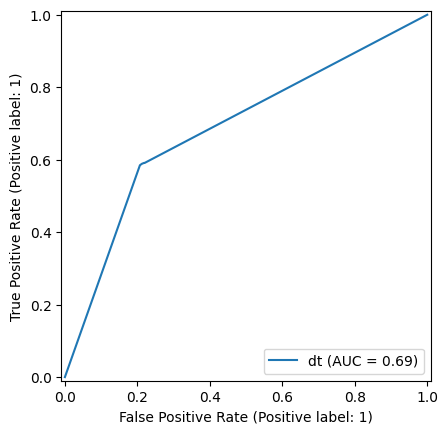

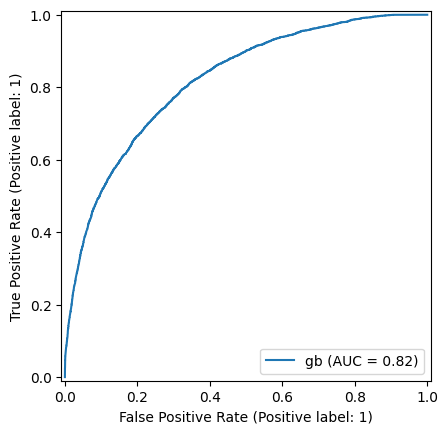

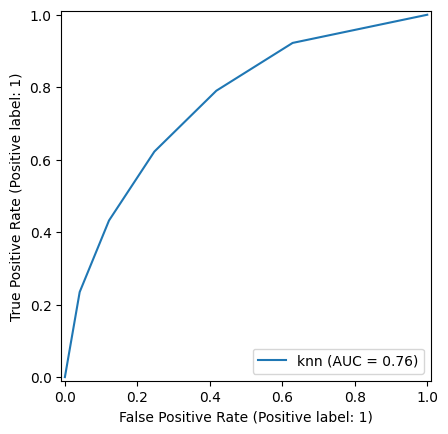

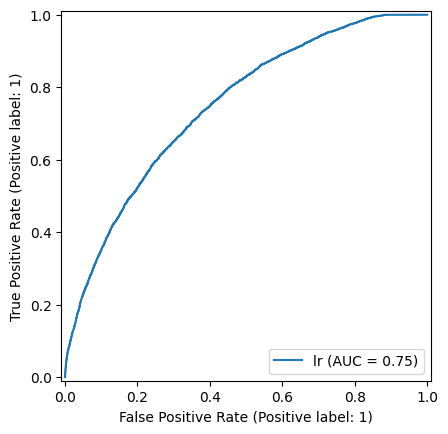

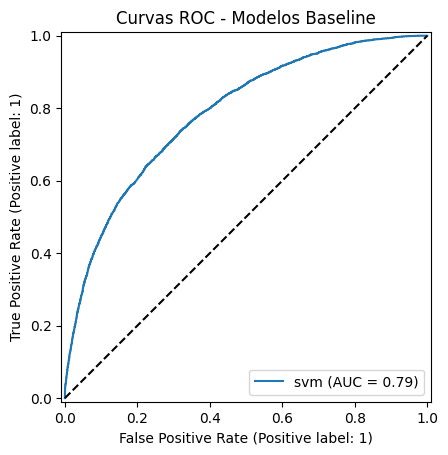

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)

plt.plot([0,1], [0,1], 'k--')
plt.title("Curvas ROC - Modelos Baseline")
plt.show()

## Análisis de Curvas ROC

Se evaluó la capacidad de discriminación de los modelos mediante curvas ROC y AUC.

###  Resultados:

- Gradient Boosting (gb) presenta el mayor AUC (~0.82), indicando mejor capacidad de discriminación global.
- SVM (~0.79) y KNN (~0.76) también muestran buen desempeño.
- Decision Tree presenta el menor AUC (~0.69), lo que sugiere menor capacidad para separar clases.

###  Trade-off importante:

- Decision Tree tiene mayor recall, pero menor AUC.
- Gradient Boosting tiene mejor AUC, pero menor recall.

###  Interpretación:

Existe un trade-off entre detectar más cancelaciones (recall) y tener un modelo más preciso en general (AUC).

Dado que el objetivo del negocio prioriza recall, el modelo Decision Tree puede ser considerado.
Sin embargo, Gradient Boosting es una mejor opción si se busca un modelo más balanceado.

# ## Evaluación del Trade-off Precision vs Recall

Las curvas Precision-Recall permiten analizar el desempeño de los modelos en la detección de la clase positiva (Cancel).

A diferencia de la curva ROC, estas son más adecuadas en contextos de clases desbalanceadas, ya que muestran el trade-off entre recall (detección de cancelaciones) y precision (exactitud de las predicciones positivas).

Se observa que el modelo Gradient Boosting presenta el mejor desempeño, logrando el mayor Average Precision (AP), lo que indica un mejor equilibrio entre detectar cancelaciones y evitar falsos positivos.

<Figure size 600x500 with 0 Axes>

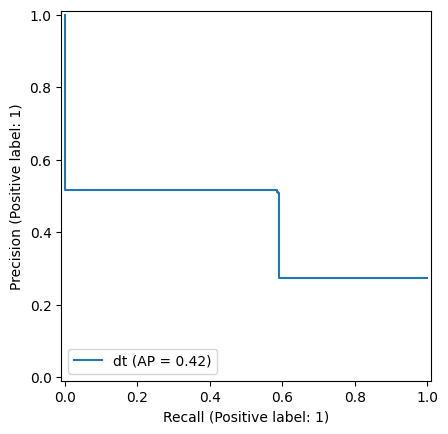

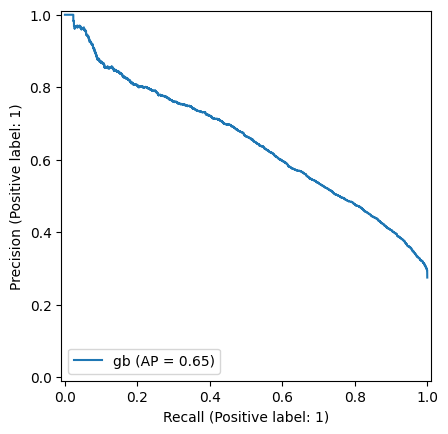

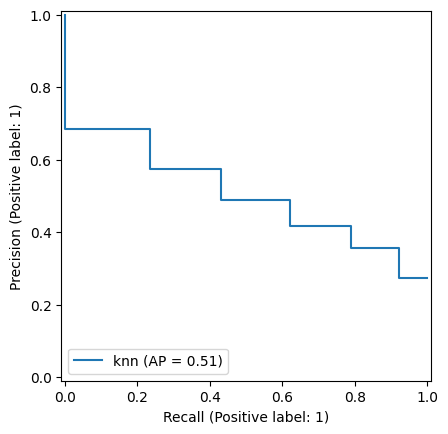

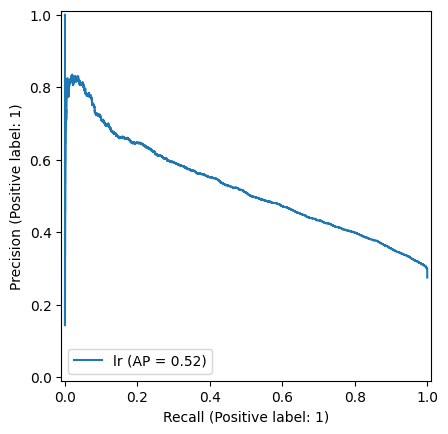

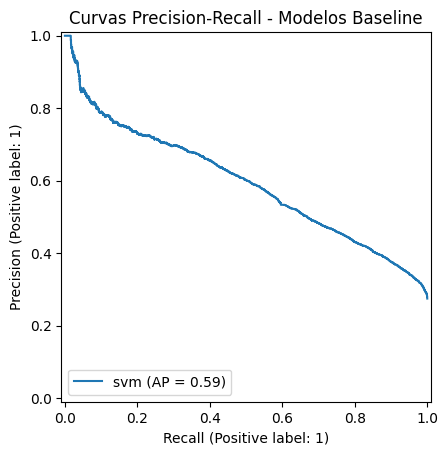

In [7]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.title("Curvas Precision-Recall - Modelos Baseline")
plt.show()